# Fundamentos de Data Science – Práctica para el Examen #

## Contexto

### La tarea es limpiar y explorar los datos para una compañía de tecnología emergente que desarrolla aplicaciones móviles. La empresa quiere mejorar la experiencia del usuario y aumentar la retención de usuarios en sus aplicaciones. Han recolectado datos sobre el uso de sus aplicaciones y quieren entender mejor cómo los usuarios interactúan con sus productos.



In [26]:

import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

In [27]:
# # Guardamos los datos en un archivo CSV
# data.to_csv('user_app_data.csv', index=False)
# print("Datos generados y guardados en 'user_app_data.csv'")

df = pd.read_csv('user_app_data.csv')
print("df : ",df)

# mostrar los primeros 10 registros
print(" primeros 10 registros : \n",df.head(10))

# los ultimos 5 registros
print("ultimos 5 registros : \n",df.tail())

# informacion general del dataframe:
print("informacion general del dataframe : \n",df.info())

# informacion estadisticas del dataframe :
print("informacion estadisticas del dataframe : \n",df.describe())


df :       user_id  app_version platform  session_duration  number_of_sessions  \
0          1          1.2  Android               109                  11   
1          2          1.3  Android               116                  17   
2          3          1.0  Android                94                  13   
3          4          1.2      iOS                47                   1   
4          5          1.2      iOS                99                   2   
..       ...          ...      ...               ...                 ...   
295      296          1.3      iOS                33                   4   
296      297          1.1  Android               118                   6   
297      298          1.2  Android                65                   1   
298      299          1.0      iOS               146                   5   
299      300          1.3      iOS               177                   1   

     country  user_feedback  
0     France              1  
1         UK         

In [28]:
# 1) Limpieza de Datos:

In [29]:
# ---- El primer paso en este proceso es usar Python para limpiar los datos y dejarlos listos para el análisis. Deben: -------

# - Identificar y abordar cualquier valor duplicado.
print("Duplicados totales:", df.duplicated().sum())
# R: no se encuentran valores duplicados si se encuentran se debe realizar los siguientes comandos
# df = df.drop_duplicates()
# print("Duplicados totales despues del drop :", df.duplicated().sum())


# - Identificar y abordar cualquier dato que falte en este conjunto de datos. Trátenlos de forma adecuada.
#   Incluyan una breve descripción en el método que usan para tratar con los valores que faltan junto con una justificación 
#   para el uso de ese método.

        # verificar datos nulos en el dataframe
print("\nDatos nulos por columna : \n")
print(df.isnull().sum())


Duplicados totales: 0

Datos nulos por columna : 

user_id               0
app_version           0
platform              0
session_duration      0
number_of_sessions    0
country               0
user_feedback         0
dtype: int64


In [30]:

# transformamos a los tipos correctos cada columna deacuerdo al diccionario de datos
df = df.astype({
    'app_version': 'float64',
    'platform': 'str',
    'session_duration': 'int64',
    'number_of_sessions': 'int64',
    'country': 'str',
    'user_feedback': 'int64'
})

   # ver tipos de datos en columnas
print("tipos de datos : ",df.dtypes)


tipos de datos :  user_id                 int64
app_version           float64
platform               object
session_duration        int64
number_of_sessions      int64
country                object
user_feedback           int64
dtype: object


In [31]:

# - Identificar y abordar cualquier inconsistencia en los valores categóricos 
# (ejemplo: android, Android, ANDROID).
print("\nIdentificar y abordar cualquier inconsistencia en los valores categóricos\n")
for col in df.columns:
    valores_unicos = df[col].unique()
    print(f"• {col:20} -> {len(valores_unicos)} únicos")
    print(f"  Lista de Valores :   {valores_unicos}\n")

# no se encuentran inconsistencias en los valores categoricos


# - Identificar y abordar cualquier punto de datos inapropiados o inusuales 
# (ejemplo: tiempo de uso de 10000 horas en una semana).
print(df)


#no se encuentra datos inapropiados o incorrectos salvo la columna session_duration donde si el dato que se entrega 
# no fuera en minutos el usuario tendria una coneccion muy alta que no seria real
# EJ("si un usuario tiene una duracion de session de 164 hrs y cantidad de session de 19
# entonces tendra 3116 horas equivalen a más de 4 meses de uso ininterrumpido (24/7).")



Identificar y abordar cualquier inconsistencia en los valores categóricos

• user_id              -> 300 únicos
  Lista de Valores :   [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 

In [32]:
#2) Exploración de Datos:

# El siguiente paso es completar una exploración de los datos usando Python. Esto debe incluir:

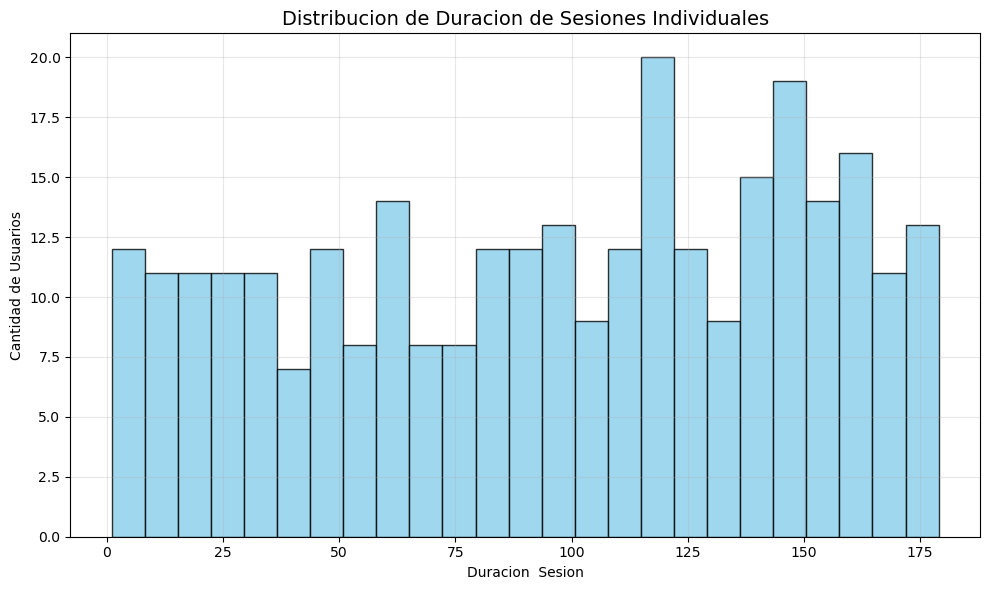

In [33]:
# Dos tipos diferentes de visualizaciones exploratorias univariantes. Cada visualización debe incluir una breve interpretación dentro del archivo de código.



df = pd.read_csv('user_app_data.csv')
df['total_duration'] = df['session_duration'] * df['number_of_sessions']

plt.figure(figsize=(10, 6))
plt.hist(df['session_duration'], bins=25, color='skyblue', edgecolor='black', alpha=0.8)
plt.title('Distribucion de Duracion de Sesiones Individuales', fontsize=14)
plt.xlabel('Duracion  Sesion')
plt.ylabel('Cantidad de Usuarios')
plt.grid(True, alpha=0.3)



plt.tight_layout()
plt.show()

# Interpretación


#### La duración de las sesiones se distribuye de forma bastante uniforme entre 0 y 175 unidades, sin picos extremos. Sugiere un uso variado entre usuarios.

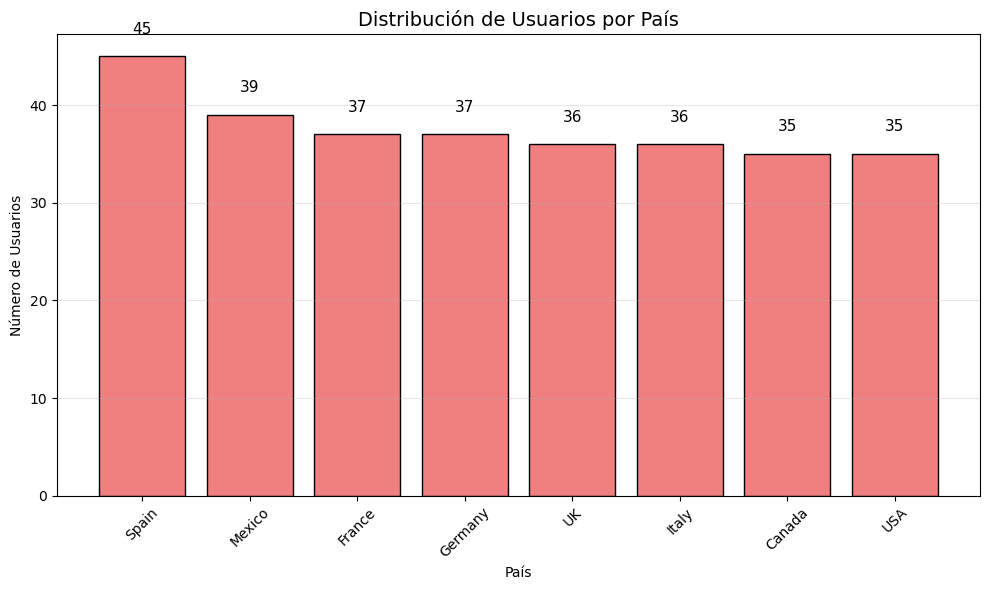

In [34]:
# Visualización 2
country_counts = df['country'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(country_counts.index, country_counts.values, color='lightcoral', edgecolor='black')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 2, 
             f'{int(height)}', ha='center', va='bottom', fontsize=11)

plt.title('Distribución de Usuarios por País', fontsize=14)
plt.xlabel('País')
plt.ylabel('Número de Usuarios')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Interpretación. 

#### Los usuarios están distribuidos de forma pareja entre 8 paises. España  tiene ligeramente más usuarios.

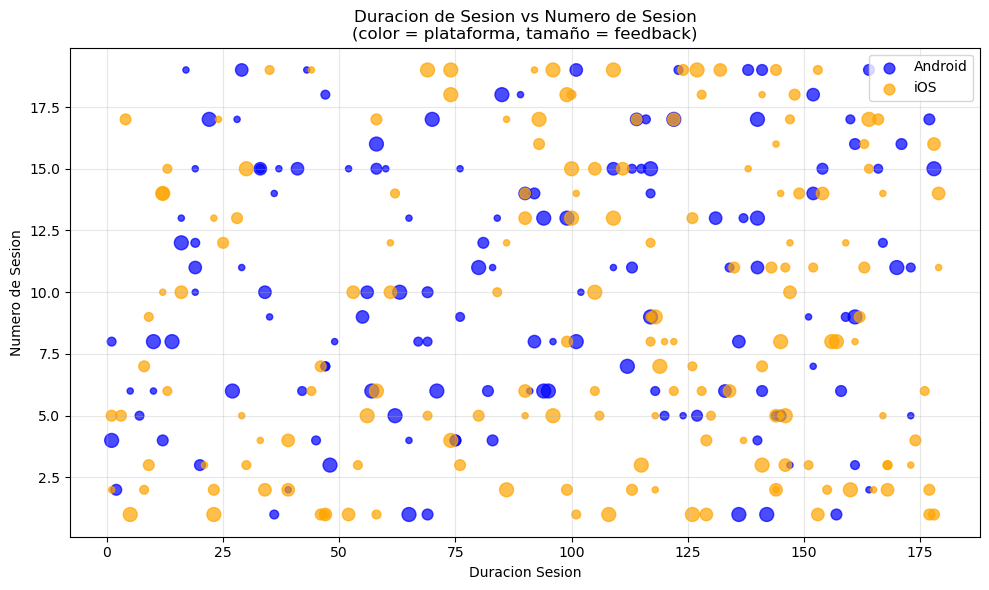

In [35]:
df = pd.read_csv('user_app_data.csv')
df['total_duration'] = df['session_duration'] * df['number_of_sessions']

# --- Visualización 1 ---
plt.figure(figsize=(10, 6))
colors = {'Android': 'blue', 'iOS': 'orange'}

for platform in df['platform'].unique():
    subset = df[df['platform'] == platform]
    plt.scatter(subset['session_duration'], 
                subset['number_of_sessions'], 
                s=subset['user_feedback'] * 20, 
                c=colors[platform], 
                alpha=0.7, label=platform)

plt.title('Duracion de Sesion vs Numero de Sesion\n(color = plataforma, tamaño = feedback)')
plt.xlabel('Duracion Sesion')
plt.ylabel('Numero de Sesion')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Interpretación
#### No se observa una correlación clara entre duración de sesión y número de sesiones. Los usuarios de Android tienden a tener más  sesiones en el rango alto. Los círculos más grandes (mejor feedback) están distribuidos en todo el rango.

<Figure size 1200x700 with 0 Axes>

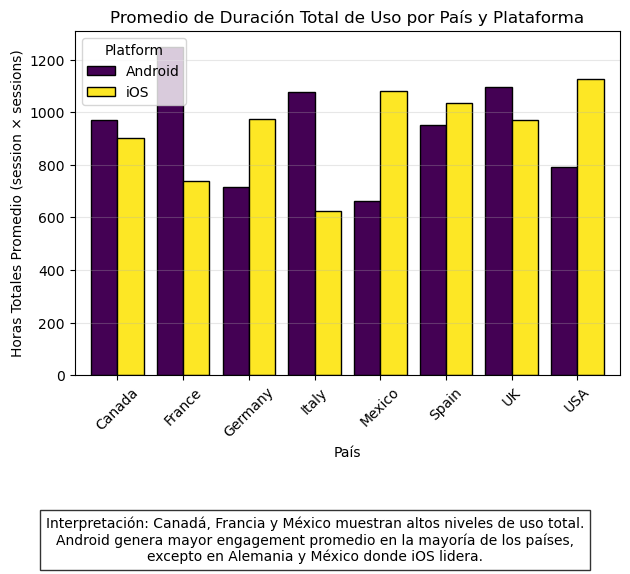

In [36]:
# --- Visualización 2 ---
avg_duration = df.groupby(['country', 'platform'])['total_duration'].mean().unstack()

plt.figure(figsize=(12, 7))
avg_duration.plot(kind='bar', width=0.8, colormap='viridis', edgecolor='black')

plt.title('Promedio de Duración Total de Uso por País y Plataforma')
plt.xlabel('País')
plt.ylabel('Horas Totales Promedio (session × sessions)')
plt.legend(title='Platform')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.figtext(0.5, -0.18, 
            'Interpretación: Canadá, Francia y México muestran altos niveles de uso total.\n'
            'Android genera mayor engagement promedio en la mayoría de los países,\n'
            'excepto en Alemania y México donde iOS lidera.', 
            ha='center', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Interpretacion

#### Se observa que en los paises como francia,italia y UK hay un alto usa de android y que en paises como alemania y mexico es muy bajo su uso. y el pais con mas uso de Ios es USA.